**VisDrone Object Detection: Final Training and Evaluation**

In [ ]:
!pip install -q ultralytics
import glob, math, random, yaml, os, torch
from ultralytics.data.utils import check_det_dataset

print("GPU:", torch.cuda.is_available(), torch.cuda.device_count())

info = check_det_dataset("VisDrone.yaml")
root = str(info["path"])
print("Root:", root)
names = ["pedestrian","people","bicycle","car","van","truck","tricycle","awning-tricycle","bus","motor"]

random.seed(0)
img_classes = {}
for lf in sorted(glob.glob(f"{root}/labels/train/*.txt")):
    img = lf.replace("/labels/", "/images/").replace(".txt", ".jpg")
    img_classes[img] = {int(l.split()[0]) for l in open(lf)}
N = len(img_classes)
freq = {c: sum(c in s for s in img_classes.values()) / N for c in range(10)}
rep = {c: min(4.0, max(1.0, math.sqrt(0.5 / f))) for c, f in freq.items()}
lines = []
for img, cs in img_classes.items():
    r = max(rep[c] for c in cs) if cs else 1.0
    n = int(r) + (random.random() < r - int(r))
    lines += [img] * max(1, n)
open("/kaggle/working/train_oversampled.txt", "w").write("\n".join(lines))
yaml.dump({"path": root, "train": "/kaggle/working/train_oversampled.txt",
           "val": "images/val", "names": dict(enumerate(names))},
          open("/kaggle/working/visdrone_os.yaml", "w"), sort_keys=False)
print(f"Train images: {N} -> {len(lines)}")

ckpt = glob.glob("/kaggle/input/**/last.pt", recursive=True)
print("Checkpoint:", ckpt)

**YOLO11s and 960px:**

In [2]:
from ultralytics import YOLO

model = YOLO(ckpt[0])
model.train(
    data="/kaggle/working/visdrone_os.yaml",
    epochs=10, imgsz=960, batch=8,
    seed=0, workers=2, device=0,
    warmup_epochs=1, close_mosaic=5,
    project="/kaggle/working/runs", name="s_960_cont",
    save_period=2, exist_ok=True,
)

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/visdrone_os.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/input/datasets/ruhabtahir31202/yolo11s-ckpt/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=s_960_cont

/usr/local/lib/python3.13/dist-packages/ray/train/_internal/session.py:683: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/10      6.84G        1.4      1.028     0.9327        381        960: 100% ━━━━━━━━━━━━ 1018/1018 4.1it/s 4:090.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 4.6it/s 7.5s0.2s
                   all        548      38759      0.509      0.417      0.418      0.248

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/10      6.84G      1.383     0.9998     0.9254        251        960: 100% ━━━━━━━━━━━━ 1018/1018 4.1it/s 4:100.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 4.3it/s 8.1s0.2s
                   all        548      38759      0.537      0.423      0.427       0.25

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/10      9.34G      1.376     0.9788     0.9232        191        960: 100% ━━━━━━━━━━━━ 1018/1018 4.1it/s 4:090.5s
                 Class     Ima

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bd81c10d220>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [3]:
import shutil, os
d = "/kaggle/working/runs/s_960_cont"
os.makedirs("/kaggle/working/export", exist_ok=True)
for f in ["weights/best.pt", "results.csv", "results.png", "confusion_matrix.png",
          "confusion_matrix_normalized.png", "BoxPR_curve.png"]:
    if os.path.exists(f"{d}/{f}"):
        shutil.copy(f"{d}/{f}", "/kaggle/working/export/")
print(os.listdir("/kaggle/working/export"))

['BoxPR_curve.png', 'confusion_matrix.png', 'results.csv', 'confusion_matrix_normalized.png', 'results.png', 'best.pt']


In [4]:
import shutil
shutil.make_archive("/kaggle/working/final_export", "zip", "/kaggle/working/export")
print("done")

done


**Evaluation After Training:**

In [5]:
import pandas as pd
from ultralytics import YOLO

m = YOLO("/kaggle/working/export/best.pt")
r = m.val(data="/kaggle/working/visdrone_os.yaml", imgsz=960, split="val",
          max_det=1000, batch=8, plots=True, project="/kaggle/working/eval", name="final")
pc = pd.DataFrame({"class": [m.names[i] for i in r.box.ap_class_index],
                   "AP50": r.box.ap50.round(3), "AP50-95": r.box.ap.round(3)})
print(f"mAP50={r.box.map50:.3f}  mAP50-95={r.box.map:.3f}")
print(pc)
pc.to_csv("/kaggle/working/export/final_per_class.csv", index=False)

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 100 layers, 9,416,670 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2507.9±704.8 MB/s, size: 153.1 KB)
val: Scanning /kaggle/working/datasets/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 28.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 4.9it/s 14.2s0.2s
                   all        548      38759      0.576      0.455      0.473      0.285
            pedestrian        520       8844      0.645      0.506      0.555      0.266
                people        482       5125      0.622      0.379      0.421      0.166
               bicycle        364       1287      0.391      0.268      0.248      0.113
                   car        515      14064      0.766      0.825      0.843      0.598
                   van 

In [6]:
import shutil, os
shutil.copytree("/kaggle/working/eval/final", "/kaggle/working/export/eval_final", dirs_exist_ok=True)
shutil.make_archive("/kaggle/working/final_export", "zip", "/kaggle/working/export")
print(os.path.getsize("/kaggle/working/final_export.zip") / 1e6, "MB")

23.203857 MB


**Load Final Model Weights:**

In [3]:
import glob, os, shutil
src = glob.glob("/kaggle/input/**/best.pt", recursive=True)
print("Found:", src)
assert src, "best.pt not found. Check that yolo11s-final is added as input."
os.makedirs("/kaggle/working/export", exist_ok=True)
shutil.copy(src[0], "/kaggle/working/export/best.pt")
print("Copied to /kaggle/working/export/best.pt")

Found: ['/kaggle/input/datasets/ruhabtahir31202/yolo11s-final/best.pt']
Copied to /kaggle/working/export/best.pt


**Final Evaluation and Result Tables:**

In [4]:
import os, pandas as pd
from ultralytics import YOLO

os.makedirs("/kaggle/working/export", exist_ok=True)
m = YOLO("/kaggle/working/export/best.pt")

def run(split):
    r = m.val(data="VisDrone.yaml", split=split, imgsz=960, max_det=1000, batch=8,
              plots=False, project="/kaggle/working/eval", name=f"final_{split}", exist_ok=True)
    pc = pd.DataFrame({"class": [m.names[i] for i in r.box.ap_class_index],
                       "P": r.box.p.round(3), "R": r.box.r.round(3),
                       "AP50": r.box.ap50.round(3), "AP50-95": r.box.ap.round(3)})
    return round(float(r.box.map50), 3), round(float(r.box.map), 3), pc

v50, v95, v_pc = run("val")
t50, t95, t_pc = run("test")

per_class = v_pc.merge(t_pc, on="class", suffixes=("_val", "_test"))
overall = pd.DataFrame([
    ["YOLO11n", 640, "none (baseline)", 0.263, 0.145, "-", "-"],
    ["YOLO11n", 640, "oversampling",    0.274, 0.151, "-", "-"],
    ["YOLO11s", 960, "oversampling",    v50, v95, t50, t95],
], columns=["model", "imgsz", "imbalance strategy", "val mAP50", "val mAP50-95",
            "test mAP50", "test mAP50-95"])

def md(df):
    cols = list(df.columns)
    out = ["| " + " | ".join(cols) + " |", "|" + "---|" * len(cols)]
    out += ["| " + " | ".join(str(x) for x in row) + " |" for row in df.values]
    return "\n".join(out)

overall.to_csv("/kaggle/working/export/overall_metrics.csv", index=False)
per_class.to_csv("/kaggle/working/export/per_class_metrics.csv", index=False)
open("/kaggle/working/export/results.md", "w").write(
    "## Overall\n" + md(overall) + "\n\n## Per class\n" + md(per_class))
print(overall.to_string(index=False)); print(); print(per_class.to_string(index=False))

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 100 layers, 9,416,670 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2270.6±700.5 MB/s, size: 188.8 KB)
val: Scanning /kaggle/working/datasets/VisDrone/labels/val... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 853.9it/s 0.6s0.0s
val: New cache created: /kaggle/working/datasets/VisDrone/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 6.4it/s 10.9s0.1s
                   all        548      38759      0.576      0.455      0.473      0.285
            pedestrian        520       8844      0.645      0.506      0.555      0.266
                people        482       5125      0.622      0.379      0.421      0.166
               bicycle        364       1287      0.391      0.268      0.248      0.113
                   car        515      

**Error Analysis:**

          class  objects  found %  wrong class %  missed %
     pedestrian     8844     49.4            4.4      46.2
         people     5125     36.9            9.2      53.9
        bicycle     1287     25.3           18.0      56.7
            car    14064     81.2            2.4      16.3
            van     1975     44.8           35.7      19.5
          truck      750     37.7           24.3      38.0
       tricycle     1045     27.7           23.0      49.4
awning-tricycle      532     21.6           30.1      48.3
            bus      251     52.2           16.3      31.5
          motor     4886     48.3            9.0      42.7

Top confusions (true -> predicted):
  van -> car: 662
  people -> pedestrian: 310
  pedestrian -> people: 304
  car -> van: 266
  motor -> bicycle: 168
  people -> motor: 144
  bicycle -> motor: 140
  motor -> pedestrian: 136
  motor -> people: 113
  truck -> car: 102

False boxes in total: 7583


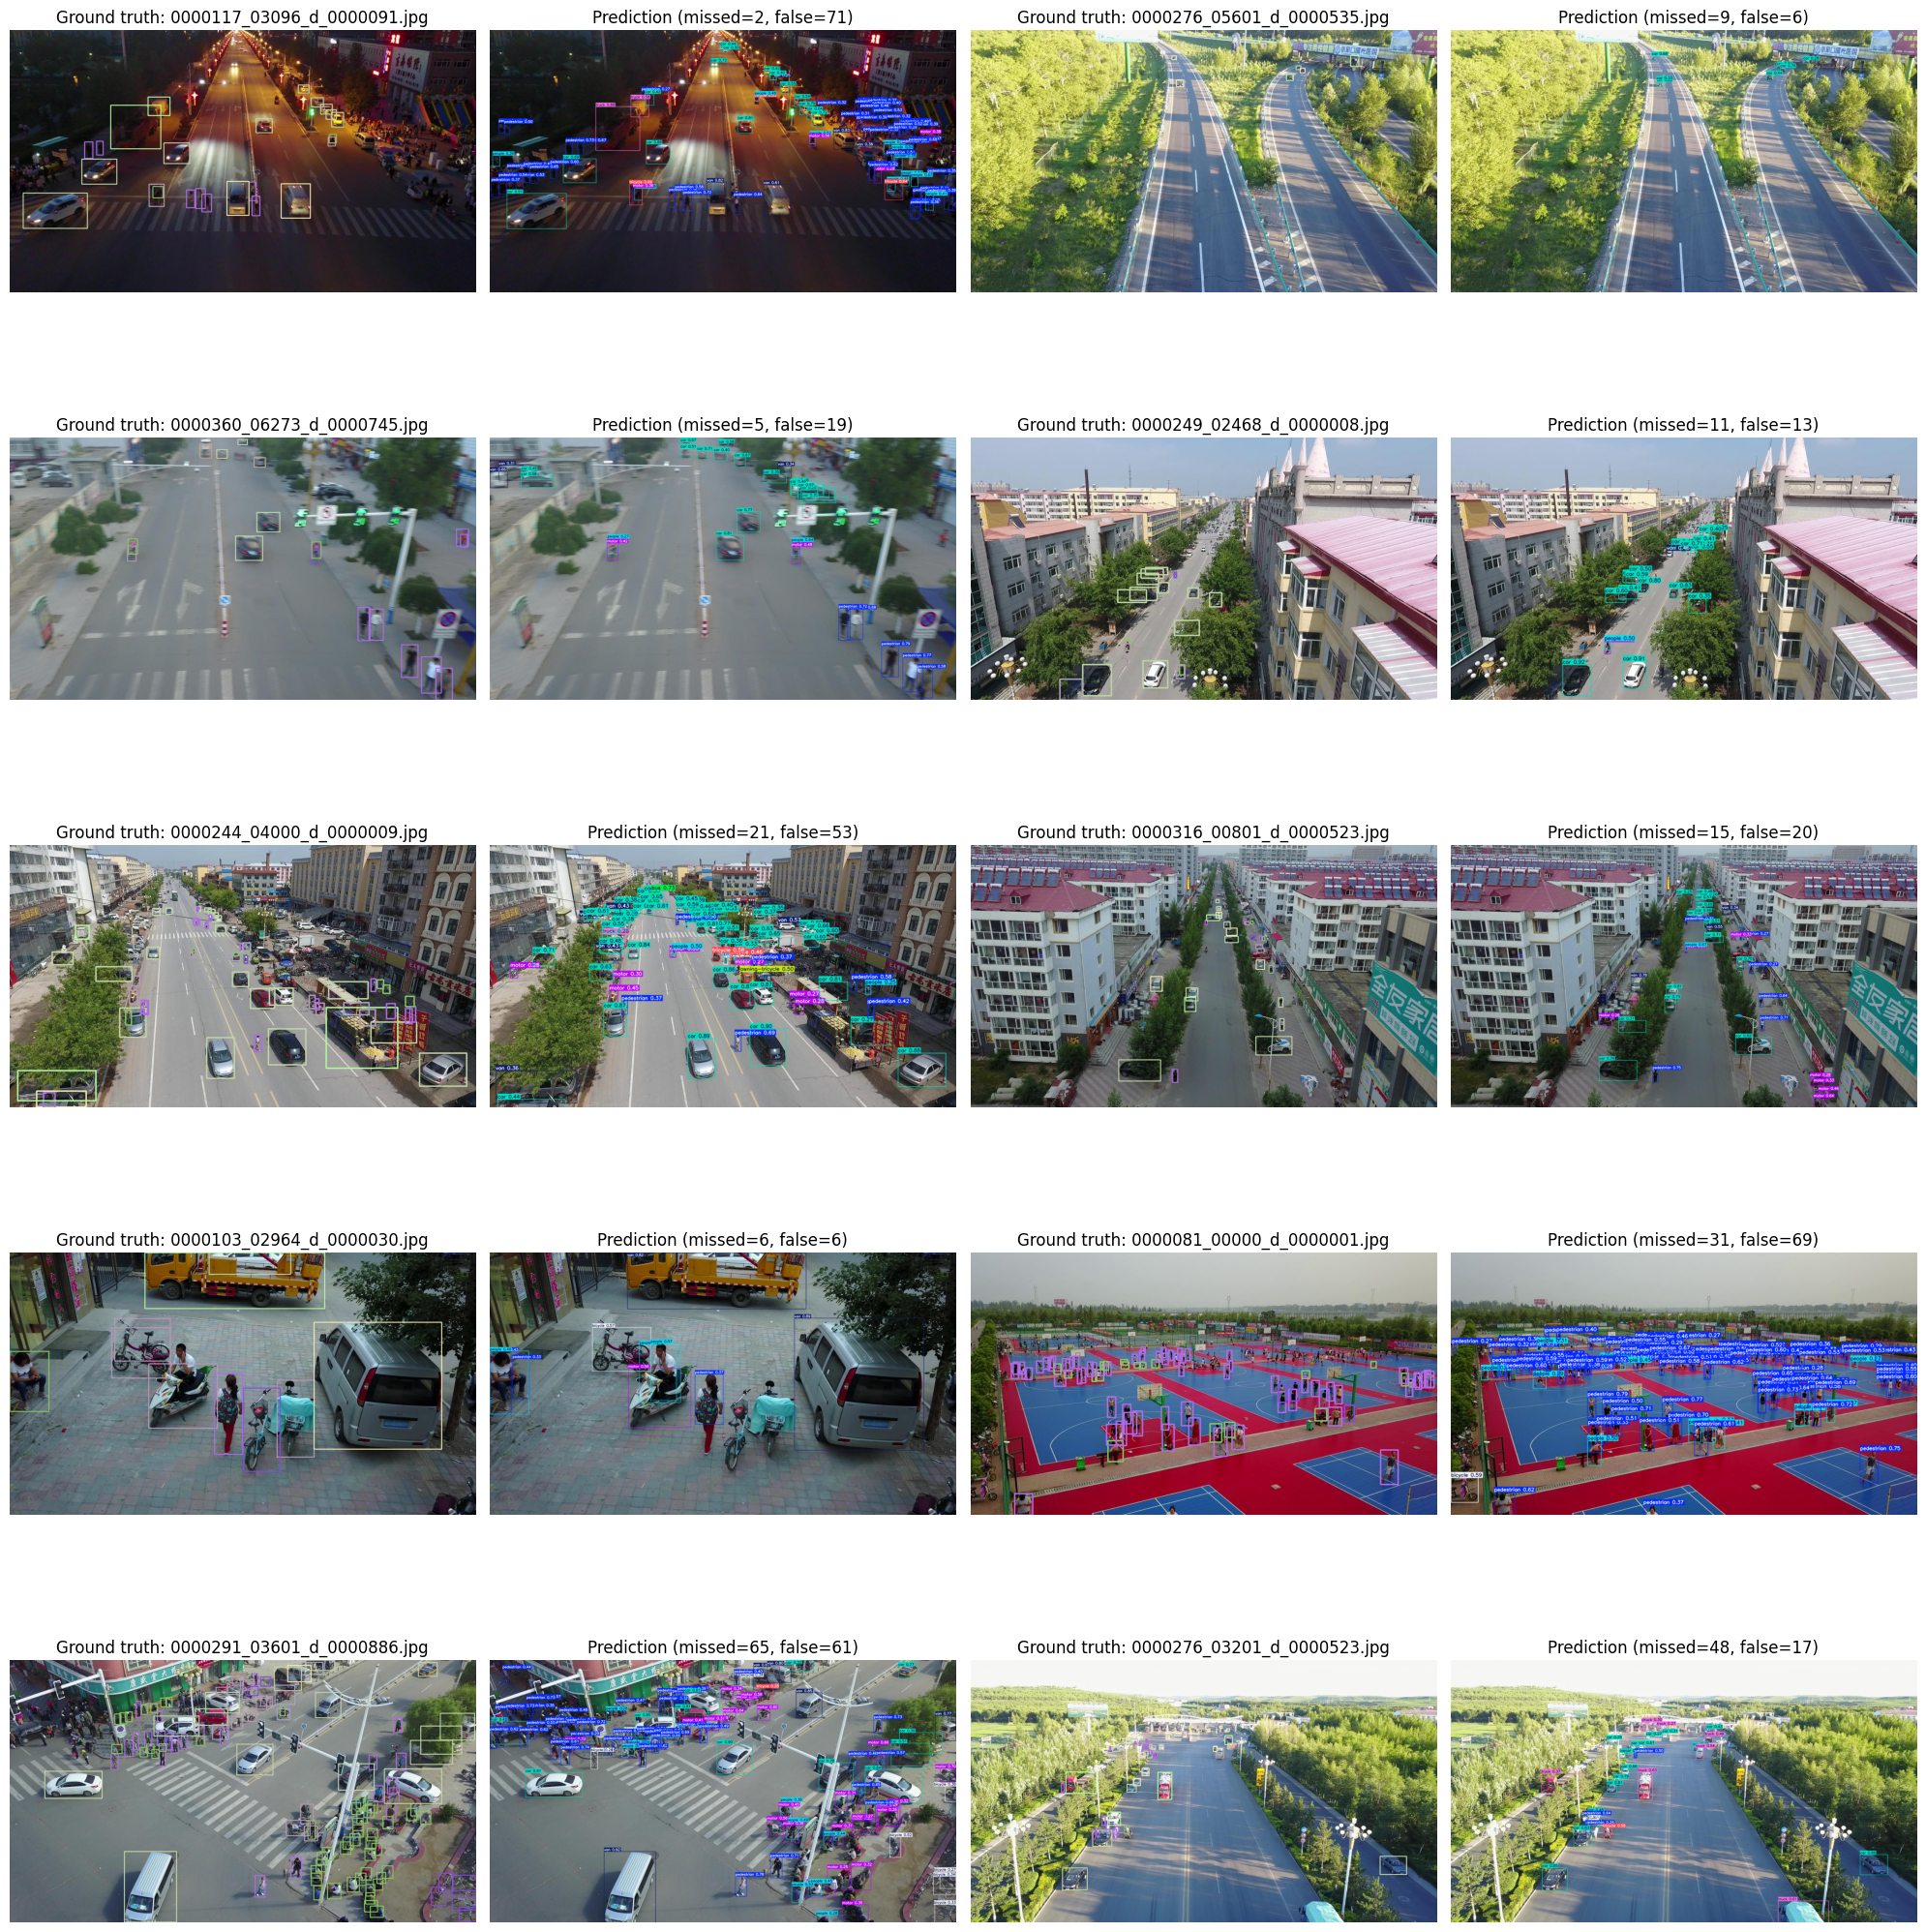

In [5]:
import os, glob, cv2, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter
from ultralytics import YOLO
from ultralytics.data.utils import check_det_dataset
from ultralytics.utils.metrics import box_iou

root = str(check_det_dataset("VisDrone.yaml")["path"])
names = ["pedestrian","people","bicycle","car","van","truck","tricycle","awning-tricycle","bus","motor"]
model = YOLO("/kaggle/working/export/best.pt")
PRED = dict(imgsz=960, conf=0.25, max_det=1000, agnostic_nms=True, verbose=False)
val_imgs = sorted(glob.glob(f"{root}/images/val/*.jpg"))
COL = [tuple(int(v) for v in np.random.RandomState(c).randint(60, 255, 3)) for c in range(10)]

def gt_of(p):
    H, W = cv2.imread(p).shape[:2]
    lbl = p.replace("/images/", "/labels/").replace(".jpg", ".txt")
    boxes, cls = [], []
    if os.path.exists(lbl):
        for l in open(lbl):
            c, x, y, w, h = l.split()
            x, y, w, h = float(x)*W, float(y)*H, float(w)*W, float(h)*H
            boxes.append([x-w/2, y-h/2, x+w/2, y+h/2]); cls.append(int(c))
    return (torch.tensor(boxes, dtype=torch.float32).reshape(len(cls), 4),
            torch.tensor(cls, dtype=torch.long))

def draw(p):
    img = cv2.imread(p); gb, gc = gt_of(p)
    for b, c in zip(gb.int().tolist(), gc.tolist()):
        cv2.rectangle(img, (b[0], b[1]), (b[2], b[3]), COL[c], 2)
    return img[..., ::-1]

res, fails = [], []
gt_total, ok_total = Counter(), Counter()
for p in val_imgs:
    gb, gc = gt_of(p)
    r = model.predict(p, **PRED)[0]
    pb, pc = r.boxes.xyxy.cpu(), r.boxes.cls.cpu().long()
    ok = torch.zeros(len(gc), dtype=torch.bool); fp = 0
    if len(pb) and len(gc):
        iou = box_iou(gb, pb)
        same = (iou > 0.5) & (gc[:, None] == pc[None, :])
        ok = same.any(1); fp = int((~same.any(0)).sum())
        for g in torch.where(~ok)[0].tolist():
            near = iou[g] > 0.5
            j = int((iou[g] * near).argmax()) if near.any() else -1
            fails.append((int(gc[g]), int(pc[j]) if j >= 0 else -1))
    else:
        fp = len(pb)
        fails += [(int(c), -1) for c in gc]
    for c, o in zip(gc.tolist(), ok.tolist()):
        gt_total[c] += 1; ok_total[c] += int(o)
    fn = int((~ok).sum())
    res.append((p, fn, fp, (fn + fp) / max(1, len(gc)), len(gc)))

fdf = pd.DataFrame(fails, columns=["t", "p"])
rows = []
for c, n in enumerate(names):
    tot = max(gt_total[c], 1); sub = fdf[fdf.t == c]
    rows.append([n, gt_total[c], round(100*ok_total[c]/tot, 1),
                 round(100*(sub.p >= 0).sum()/tot, 1), round(100*(sub.p < 0).sum()/tot, 1)])
summary = pd.DataFrame(rows, columns=["class", "objects", "found %", "wrong class %", "missed %"])
print(summary.to_string(index=False))
print("\nTop confusions (true -> predicted):")
for (t_, p_), n in fdf[fdf.p >= 0].groupby(["t", "p"]).size().sort_values(ascending=False).head(10).items():
    print(f"  {names[t_]} -> {names[p_]}: {n}")
print("\nFalse boxes in total:", sum(x[2] for x in res))
summary.to_csv("/kaggle/working/export/error_summary.csv", index=False)

worst = sorted([x for x in res if x[4] >= 5], key=lambda x: -x[3])[:10]
fig, axs = plt.subplots(5, 4, figsize=(20, 22))
for i, (p, fn, fp, _, _) in enumerate(worst):
    r = model.predict(p, **PRED)[0]
    a, b = axs[i // 2][(i % 2) * 2], axs[i // 2][(i % 2) * 2 + 1]
    a.imshow(draw(p)); a.set_title(f"Ground truth: {os.path.basename(p)}")
    b.imshow(r.plot(line_width=1)[..., ::-1]); b.set_title(f"Prediction (missed={fn}, false={fp})")
for ax in axs.ravel(): ax.axis("off")
plt.tight_layout(); plt.savefig("/kaggle/working/export/failure_examples.png", dpi=80); plt.show()

**Confidence Threshold Sweep:**

In [6]:
store = []
for p in val_imgs:
    gb, gc = gt_of(p)
    r = model.predict(p, **{**PRED, "conf": 0.15})[0]
    store.append((gb, gc, r.boxes.xyxy.cpu(), r.boxes.cls.cpu().long(), r.boxes.conf.cpu()))

rows = []
for t in [0.15, 0.25, 0.30, 0.35, 0.40, 0.50]:
    found = fp = gt = pred = 0
    for gb, gc, pb, pc, cf in store:
        k = cf >= t
        pb, pc = pb[k], pc[k]
        gt += len(gc); pred += len(pc)
        if len(pb) and len(gc):
            same = (box_iou(gb, pb) > 0.5) & (gc[:, None] == pc[None, :])
            found += int(same.any(1).sum()); fp += int((~same.any(0)).sum())
        else:
            fp += len(pb)
    rows.append([t, found, round(100*found/gt, 1), fp,
                 round(fp/len(store), 1), round(100*(pred-fp)/max(pred, 1), 1)])
sweep = pd.DataFrame(rows, columns=["conf", "found", "found %", "false boxes",
                                    "false per image", "precision %"])
print(sweep.to_string(index=False))
sweep.to_csv("/kaggle/working/export/conf_sweep.csv", index=False)

 conf  found  found %  false boxes  false per image  precision %
 0.15  24326     62.8        14952             27.3         64.6
 0.25  22069     56.9         7583             13.8         75.3
 0.30  20900     53.9         5646             10.3         79.2
 0.35  19657     50.7         4277              7.8         82.3
 0.40  18403     47.5         3297              6.0         84.8
 0.50  15703     40.5         1955              3.6         88.9
